# LiL-Q: Linear-in-Learnables Quasilinearized Solvers for PDEs
This interactive notebook demonstrates the **LiL-Q** (Linear-in-Learnables Quasilinearized) implementation across three research problems currently supported in this repository:

1. **Linear Elasticity** — A solid mechanics problem modeled as a system of linear PDEs. Since it is linear, **LiL-Q** converges in a **single step**.
2. **Kovasznay Flow** — A steady 2D incompressible Navier-Stokes formulation. Convective quadratic nonlinearities are resolved using successive Bellman-Kalaba quasilinearization, producing a sequence of linear subproblems.
3. **Bratu Equation** — A classical highly nonlinear elliptic PDE modeling thermal combustion, solved via successive linearization and direct QR.


## 1. Setup the Environment
First, we insert the repository root into our system paths so we can import directly from our folders.

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Insert the parent directory to allow importing from the core modules
repo_root = Path(os.path.abspath('')).parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Environment setup successful! Root directory:", repo_root)

Environment setup successful! Root directory: c:\Users\awoji\Documents\LiL-Q\Refactored Codebase


## 2. Configure LiL-Q
Select the problem you want to run. You can configure: 
- `PROBLEM`: Choose between `"LinearElasticity"`, `"Kovasznay"`, or `"Bratu"`.
- `N_SIZE`: Chebyshev or Fourier basis size $N$ per dimension ($P = N^2$ DOFs per field).
- `BASIS_TYPE`: Specify the exact basis combinations to be used (e.g. Fourier, Chebyshev, etc.).

In [2]:
# =============================================================================
# INTERACTIVE RUNNER CONFIGURATION
# =============================================================================
PROBLEM = "Bratu"   # Options: "LinearElasticity", "Kovasznay", "Bratu"

# Setup the exact default implementations used in the paper experiments:
if PROBLEM == "LinearElasticity":
    N_SIZE = 15                 # Default paper N size per dimension
    BASIS_TYPE_U = "cos_sin"    # u_x field basis
    BASIS_TYPE_V = "sin_cheb"   # u_y field basis
    print(f"Configured: {PROBLEM} (DOFs per field: {N_SIZE**2})")
    print(f"u_x Basis: {BASIS_TYPE_U}, u_y Basis: {BASIS_TYPE_V}")
    
elif PROBLEM == "Kovasznay":
    N_SIZE = 15                 # Default paper N size per dimension
    BASIS_TYPE_U = "chebyshev"  # u velocity basis
    BASIS_TYPE_V = "chebyshev"  # v velocity basis
    BASIS_TYPE_P = "chebyshev"  # pressure basis
    print(f"Configured: {PROBLEM} (DOFs per field: {N_SIZE**2})")
    print(f"All velocity/pressure fields configured with: {BASIS_TYPE_U}")
    
elif PROBLEM == "Bratu":
    N_SIZE = 15                 # Default paper N size per dimension
    BASIS_TYPE = "fourier"      # Try: "fourier", "chebyshev", "sin_sin"
    print(f"Configured: {PROBLEM} (DOFs: {N_SIZE**2})")
    print(f"Elliptic basis configured with: {BASIS_TYPE}")

Configured: Bratu (DOFs: 225)
Elliptic basis configured with: fourier


## 3. Initialize the Core Physics & Collocation Discretizations
We now dynamically import the solver modules and initialize the collocation operator grids based on your configuration.

In [3]:
if PROBLEM == "LinearElasticity":
    from LinearElasticity.elasticity_core import (
        ElasticityPhysics, ElasticityDiscretization,
        create_elasticity_basis, solve_lil_elasticity,
        evaluate_all_fields, evaluate_exact_fields
    )
    # Initialize Elasticity Physics
    physics = ElasticityPhysics()
    disc = ElasticityDiscretization(
        N_x=N_SIZE, N_y=N_SIZE, k_ratio=10,
        collocation_ratios=(0.85, 0.15), seed=42
    )
    basis_u = create_elasticity_basis(BASIS_TYPE_U, N_SIZE, N_SIZE, physics.x_domain, physics.y_domain)
    basis_v = create_elasticity_basis(BASIS_TYPE_V, N_SIZE, N_SIZE, physics.x_domain, physics.y_domain)
    print("Initialized 2D Plane-Strain Linear Elasticity.")

elif PROBLEM == "Kovasznay":
    from Kovasznay.kovasznay_core import (
        KovasznayPhysics, KovasznayDiscretization,
        create_kovasznay_basis, solve_lilq_kovasznay,
        evaluate_all_fields, evaluate_exact_fields
    )
    # Initialize Navier-Stokes Kovasznay Physics
    physics = KovasznayPhysics(Re=40.0, x_domain=(-0.5, 1.0), y_domain=(-0.5, 1.5))
    disc = KovasznayDiscretization(
        N_x=N_SIZE, N_y=N_SIZE, k_ratio=4,
        collocation_ratios=(0.8, 0.1, 0.1), seed=42
    )
    basis_u = create_kovasznay_basis(BASIS_TYPE_U, N_SIZE, N_SIZE, physics.x_domain, physics.y_domain)
    basis_v = create_kovasznay_basis(BASIS_TYPE_V, N_SIZE, N_SIZE, physics.x_domain, physics.y_domain)
    basis_p = create_kovasznay_basis(BASIS_TYPE_P, N_SIZE, N_SIZE, physics.x_domain, physics.y_domain)
    print(f"Initialized Steady Navier-Stokes Kovasznay Flow (Reynolds Re = {physics.Re}).")

elif PROBLEM == "Bratu":
    from Bratu.bratu_core import (
        BratuPhysics, DiscretizationConfig, OptimizationConfig,
        solve_quasilinear_lil, evaluate_lil_solution, create_bratu_basis
    )
    # Initialize Bratu Physics
    physics = BratuPhysics(lambda_=6.2)
    disc = DiscretizationConfig(N_x=N_SIZE, N_y=N_SIZE)
    opt = OptimizationConfig()
    basis = create_bratu_basis(basis_type=BASIS_TYPE, N_x=N_SIZE, N_y=N_SIZE)
    print("Initialized Bratu.")

c:\Users\awoji\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Initialized Bratu.


## 4. Run LiL-Q

In [4]:
import time
start_time = time.time()
print(f"Executing LiL-Q for: {PROBLEM}...")

if PROBLEM == "LinearElasticity":
    result = solve_lil_elasticity(
        physics, disc, basis_u, basis_v,
        lambda_pde=1.0, lambda_bc=10.0, bc_mode="paper",
        verbose=True
    )
    theta_u, theta_v = result['theta_u'], result['theta_v']
    total_dofs = len(theta_u) + len(theta_v)

elif PROBLEM == "Kovasznay":
    result = solve_lilq_kovasznay(
        physics, disc, basis_u, basis_v, basis_p,
        lambda_mom=1.0, lambda_cont=1.0, lambda_bc=10.0,
        max_iter=20, tol=1e-9, verbose=True
    )
    theta_u, theta_v, theta_p = result['theta_u'], result['theta_v'], result['theta_p']
    total_dofs = len(theta_u) + len(theta_v) + len(theta_p)

elif PROBLEM == "Bratu":
    basis_obj, coeffs, metrics, summary = solve_quasilinear_lil(
        physics=physics, discretization=disc, optimization=opt,
        basis=basis, verbose=True
    )
    total_dofs = len(coeffs)

elapsed = time.time() - start_time
print(f"\nComplete!")
print(f"Total DOFs solved: {total_dofs}")
print(f"Execution time: {elapsed:.4f} seconds")

Executing LiL-Q for: Bratu...
METHOD: Quasilinear LiL (LiL-Q)
  Basis: TensorProductBasis2D(
  x: Fourier1D(n_basis=15, domain=(0.0, 1.0)),
  y: Fourier1D(n_basis=15, domain=(0.0, 1.0)),
  total: 225 basis functions
)
  Coefficients: 225
  Pre-training loss: 0.000000e+00
  Initial loss: 3.844000e+01
  Converged at iteration 3

Complete!
Total DOFs solved: 225
Execution time: 0.2306 seconds


## 5. Visualize the 2D Fields
We evaluate the coefficients on a grid and plot the solution fields.

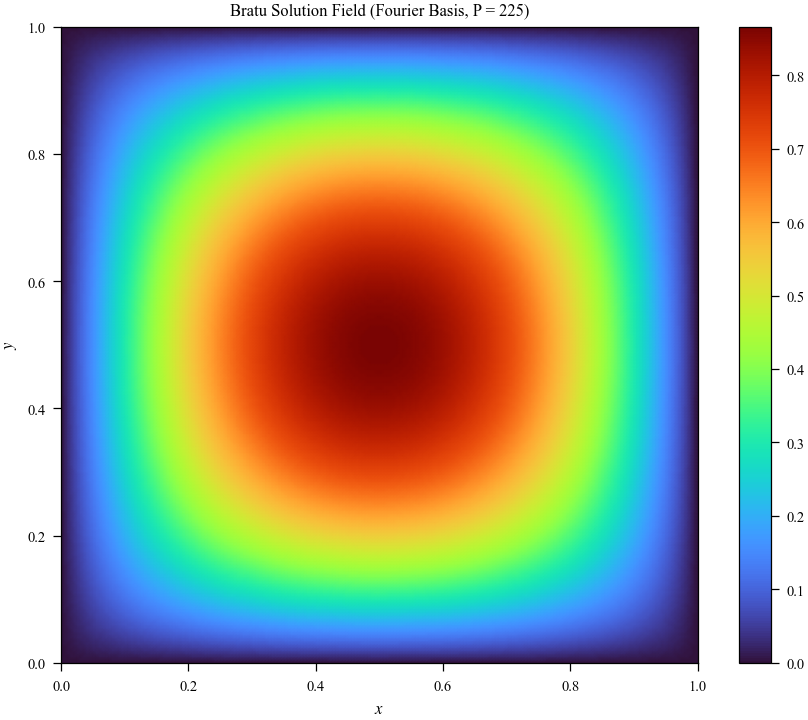

In [5]:
if PROBLEM == "LinearElasticity":
    pred = evaluate_all_fields(basis_u, basis_v, theta_u, theta_v, physics, n_eval=200)
    X, Y = pred['X'], pred['Y']
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
    
    # Plot u_x
    pcm1 = axes[0].pcolormesh(X, Y, pred['ux'], cmap='jet', shading='gouraud')
    axes[0].set_aspect('equal')
    axes[0].set_xlabel(r'$x$'); axes[0].set_ylabel(r'$y$')
    axes[0].set_title(r'$u_x$ Displacement Field')
    fig.colorbar(pcm1, ax=axes[0])
    
    # Plot u_y
    pcm2 = axes[1].pcolormesh(X, Y, pred['uy'], cmap='jet', shading='gouraud')
    axes[1].set_aspect('equal')
    axes[1].set_xlabel(r'$x$')
    axes[1].set_title(r'$u_y$ Displacement Field')
    fig.colorbar(pcm2, ax=axes[1])
    
    plt.tight_layout()
    plt.show()

elif PROBLEM == "Kovasznay":
    pred = evaluate_all_fields(basis_u, basis_v, basis_p, theta_u, theta_v, theta_p, physics, n_eval=200)
    X, Y = pred['X'], pred['Y']
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=150)
    
    # Plot Velocity u
    pcm1 = axes[0].pcolormesh(X, Y, pred['u'], cmap='jet', shading='gouraud')
    axes[0].set_aspect('equal')
    axes[0].set_xlabel(r'$x$'); axes[0].set_ylabel(r'$y$')
    axes[0].set_title('Velocity $u$ Field')
    fig.colorbar(pcm1, ax=axes[0])
    
    # Plot Velocity v
    pcm2 = axes[1].pcolormesh(X, Y, pred['v'], cmap='jet', shading='gouraud')
    axes[1].set_aspect('equal')
    axes[1].set_xlabel(r'$x$')
    axes[1].set_title('Velocity $v$ Field')
    fig.colorbar(pcm2, ax=axes[1])
    
    # Plot Pressure p
    pcm3 = axes[2].pcolormesh(X, Y, pred['p'], cmap='turbo', shading='gouraud')
    axes[2].set_aspect('equal')
    axes[2].set_xlabel(r'$x$')
    axes[2].set_title('Pressure $p$ Field')
    fig.colorbar(pcm3, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

elif PROBLEM == "Bratu":
    X, Y, U = evaluate_lil_solution(basis, coeffs, physics, disc)
    
    fig, ax = plt.subplots(figsize=(6.2, 5.0), dpi=150)
    pcm = ax.pcolormesh(X, Y, U, cmap='turbo', shading='gouraud')
    ax.set_aspect('equal')
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())
    ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
    ax.set_title(f'Bratu Solution Field ({BASIS_TYPE.capitalize()} Basis, P = {N_SIZE**2})')
    fig.colorbar(pcm, ax=ax)
    
    plt.tight_layout()
    plt.show()